# Lab 5: Multimodal Prompting

This exercise shows how multimodal embeddings can be used for search and retrieval with a sample product dataset. Amazon Titan Multimodal embeddings and the Amazon OpenSearch service will be utilized to enable semantic search based on multiple modalities like title, description and images. This allows finding related products that share conceptual and visual similarities beyond just textual matches.

#### About This Lab

    Throughout this lab, you will encounter two types of interactive elements:

                ![Activity](../mlu_utils/activity.png)

                ![Challenge](../mlu_utils/challenge.png)

                No coding is needed for an activity. You try to understand a concept,
answer questions, or run a code cell.

                Challenges are where you test your understanding by implementing something new or taking a short quiz.

    Please work through this notebook from top to bottom to avoid errors due to missing code or context.

## Table of Contents

## 1. Installing dependencies

**Note:** the pip command below might output some error messages. You can disregard them, as they are not affecting the notebook

In [1]:
!pip install --no-deps -q -r ../requirements.txt

In [2]:
import boto3
from botocore.exceptions import ClientError
import os
import base64
import json
import httpx
from IPython.display import Image, display, Markdown, IFrame
import requests

import logging
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

## 2. Prepare Image as Binary Data

There are scenarios where you need to transmit or store image data along with other types of data, such as text or structured data. Images are inherently binary data and here we are reading the images as binary data, as well as identifiyng the image type associated.
Keep in mind that, although images are inherently binary data, directly embedding them in text-based formats like JSON or HTML can be problematic. This is where Base64 encoding comes into play, providing a way to represent binary data as text.

[Base64](https://en.wikipedia.org/wiki/Base64) is an encoding scheme that converts binary data into a sequence of printable ASCII characters. This encoding is particularly useful when you need to embed binary data (like images) in text-based formats or protocols, such as JSON, HTML, or HTTP requests and responses. This can be particularly useful when working with multimodal models like Amazon Nova, which can process both text and images.

For the particular case of this notebook, as we are using AWS Converse API, which takes care of this encoding, we can provide directly the binary data.

In [3]:
def prepare_image(image_paths):
    """
    Prepare one or more image files or URLs into binary format.

    Args:
        image_paths (str or list): A single file path/URL or a list of file paths/URLs.

    Returns:
        tuple: A tuple containing two lists:
            - A list of binary images.
            - A list of corresponding image types.

    Raises:
        ValueError: If an unsupported image format is encountered.
    """
    # Convert input to list if it's a single string
    if isinstance(image_paths, str):
        image_paths = [image_paths]

    images, image_types = [], []

    # Iterate over the image paths/URLs
    for path in image_paths:
        # Check if the path is a URL
        if path.startswith("https://"):
            response = requests.get(path)
            binary_data = response.content
        # Otherwise, assume it's a file path
        else:
            with open(path, "rb") as image_file:
                binary_data = image_file.read()

        # Determine the image type based on the file extension
        if path.endswith('.png'):
            image_type = 'png'
        elif path.endswith('.jpg') or path.endswith('.jpeg'):
            image_type = 'jpeg'
        elif path.endswith('.webp'):
            image_type = 'webp'
        elif path.endswith('.gif'):
            image_type = 'gif'
        else:
            raise ValueError("Only 'jpeg', 'png', 'webp', and 'gif' image formats are currently supported")

        images.append(binary_data)
        image_types.append(image_type)

    return images, image_types

## 3. Make Multimodal Predictions

Multimodal prompting is a technique that allows language models to process and generate responses based on a combination of text and image inputs. The input consists of textual prompts or questions along with one or more images, often encoded in base64 format with types specified. The language model's architecture and training allow it to understand the relationships between text and visual information. This enables more contextual and visually grounded interactions, useful for applications like image captioning, visual question answering, and multimodal content generation. The generated response can be textual descriptions, answers, or new multimodal outputs, leveraging both modalities for enhanced capabilities.

In [4]:
def invoke_nova_lite_multimodal(prompt, images, image_types):
    """
    Invoke the Nova Lite multimodal model from Anthropic using AWS Bedrock runtime.

    Args:
        prompt (str): The text prompt to provide to the model.
        images (list): A list of base64-encoded image data.
        image_types (list): A list of MIME types corresponding to the images.

    Returns:
        str: The model's response text.

    Raises:
        ValueError: If an invalid model name is provided.
    """
    # Initialize the Amazon Bedrock runtime client
    client = boto3.client(service_name="bedrock-runtime", region_name="us-east-1")
    # select model
    model_id = "amazon.nova-lite-v1:0"
    # Build the message to call Converse API
    
    message_content = []
    for img, img_type in zip(images, image_types):
        message_content.append({"image": {"format": img_type, "source": {"bytes": img}}},)    
    message_content.append({"text": prompt})

    messages = [
            {
                "role": "user",
                "content": message_content,
            }
      ]
    inf_params = {"maxTokens": 2048, "topP": 1.0, "temperature": 0.2}

    try:
        response = client.converse(
            modelId=model_id, messages=messages, inferenceConfig=inf_params
        )
        # Process and return the response
        result = json.dumps(response, indent=2)

        return response["output"]["message"]["content"][0]["text"]
    except ClientError as err:
        logger.error(
            "Couldn't invoke Nova Lite %s model. Here's why: %s: %s",
            model_id.capitalize(),
            err.response["Error"]["Code"],
            err.response["Error"]["Message"],
        )
        raise

## 4. Prompting With Images

Let's try out the multimodal models using prompts containing both images and text.
We will use the following AI-generated image to explore the visual understanding capabilities of Amazon Nova Lite model.

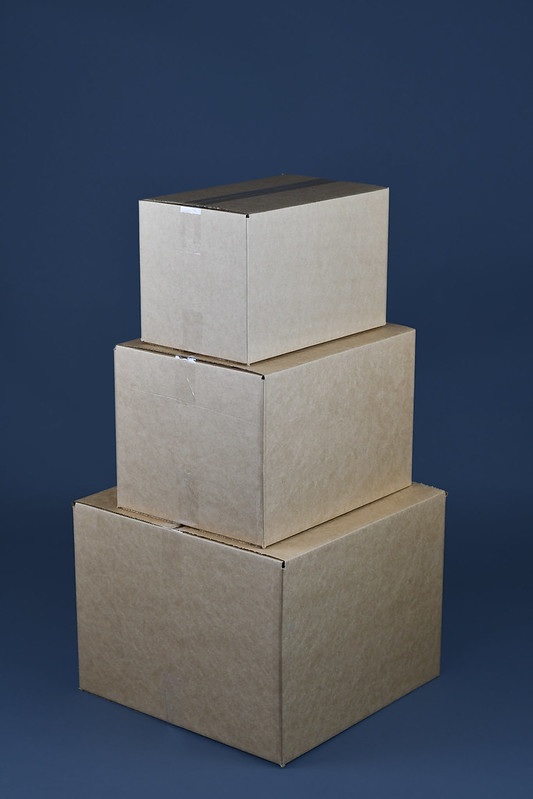

In [5]:
# View Image
Image(filename='content/stacked_boxes.jpg', width=400)

#### Loading images from local path

To prompt Amazon Nova with local images, pass them as a list in the "image" parameter of the multimodal request. This allows Nova to analyze the images along with the text prompt.

We will use the helper functions `prepare_images` and `invoke_nova_lite_multimodal` for prompting.

In [6]:
prompt = "Describe the image."
image_binary, image_type = prepare_image("content/stacked_boxes.jpg")
response = invoke_nova_lite_multimodal(prompt=prompt, images=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

<i>Three cardboard boxes are stacked on top of each other on a blue background. The boxes are brown and have a rectangular shape with a flat bottom and a lid. The boxes are stacked in a way that the top box is slightly smaller than the bottom box, and the middle box is slightly smaller than the top box. The boxes are probably used for storage or shipping purposes.</i>

In [7]:
prompt = "Count the number of boxes in the image."
image_binary, image_type = prepare_image("content/stacked_boxes.jpg")
response = invoke_nova_lite_multimodal(prompt=prompt, images=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

<i>There are three boxes stacked on top of each other in the image. The boxes are made of cardboard and have a brown color. The boxes are stacked in a way that the largest box is at the bottom, followed by a medium-sized box, and the smallest box is on top. The boxes appear to be empty, and there are no visible contents inside them. The image shows a close-up view of the boxes, and the background is a solid blue color.</i>

Multimodal models are very powerful, yet they may make mistakes when analyzing images as we might observe in the example above.

#### Loading images from url

You can also directly load images from url. The process remains pretty similar as the previous example. The image is retrieved from the url, converted into base64 string and then passed to the model.

Photo by Pixabay from Pexels under Creative Commons license (CC0): https://images.pexels.com/photos/66709/pexels-photo-66709.jpeg

In [8]:
image_url = "https://images.pexels.com/photos/66709/pexels-photo-66709.jpeg"
Image(url=image_url, width=400)

In [9]:
prompt = "Write a sonnet about the object in the image."
image_binary, image_type = prepare_image(image_url)
response = invoke_nova_lite_multimodal(prompt=prompt, images=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

<i>"Lady Liberty, you stand tall and proud,
Your torch aloft, a beacon of hope,
Your crown of stars, a symbol of freedom,
A monument to the land of the free.

Your face, serene, yet strong and wise,
Your gaze, fixed on the future with grace,
Your hand, outstretched, a welcoming sign,
A promise of refuge for all who seek.

Your gown, flowing, a testament to grace,
Your stance, firm, a symbol of strength,
Your spirit, unyielding, a beacon of light,
A guiding star for those who dare to dream.

Oh, Lady Liberty, you are more than just a statue,
You are a symbol of hope and a promise of a better tomorrow,
A reminder that freedom is a precious gift,
And one that must be cherished and protected forever."</i>

## 5. Best Practices for Multimodal Prompting

As multimodal models become more advanced and capable of understanding different data modalities like text, images, and audio, it's crucial to follow established best practices when prompting these models. Adhering to guidelines helps ensure the outputs generated are relevant and expected.

Maintain standard best practices for prompting such as providing clear and specific prompts, avoiding ambiguity, and carefully curating the data inputs. Best practices also emphasize the importance of maintaining user privacy and respecting intellectual property rights. For instance, being thoughtful about what images or audio clips are uploaded to avoid unintentionally sharing personal or copyrighted content.  

Moreover, best practices guide users on how to interpret model outputs appropriately, understanding the inherent limitations of AI systems and that responses should be validated against authoritative sources. Following these recommendations ultimately leads to more trustworthy and reliable interactions with cutting-edge AI capabilities.

#### Know your model's capabilities and limitations

It is important to consider the selected model's known capabilities and limitations while prompting the model. In this lab, we are using the Nova models which have the following guidelines for effective prompting:

Nova Lite Models:
- **Input Format**: Images need to be provided in a base64-encoded format.
- **Image Size**: Maximum image size is 5MB.
- **Multiple Images**: Nova models support prompting with multiple images.
- **Image Format**: Supported image formats: 'PNG', 'JPEG' and 'GIF'.
- **Image Clarity**: Clear images which are not too blurry are more effective with Nova models.
- **Image Resolution**: Max resolution is: 8000x8000 pixels. Very small images under 200 pixels on any given edge may lead to degraded performance.

## Activity: Text and image search

    

    ![Activity](../mlu_utils/activity.png) 
    Try prompting the Nova model with your own prompts. Explore how the quality and accuracy of responses changes with Image Resolution, Formats, Placement, etc

In [10]:
############## CODE HERE ####################
prompt = "show me the encoding channels in the image"
image_binary, image_type = prepare_image(image_url)
response = invoke_nova_lite_multimodal(prompt=prompt, images=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")
############## END OF CODE ##################

<i>The image shows a close-up view of the Statue of Liberty, focusing on her head and upper body. The statue is depicted in a greenish hue, which is typical of the patina that forms on copper over time. The statue's face is stoic and serene, with her eyes looking forward and her mouth slightly open. Her right arm is raised, holding a tablet in her left hand, which bears the inscription "JULY IV MDCCLXXVI" (July 4, 1776), representing the date of American independence. The statue's crown has seven spikes, symbolizing the seven seas and seven continents. The background is a plain, light gray sky, providing a simple and uncluttered backdrop that highlights the statue's features. The image captures the iconic status of the Statue of Liberty as a symbol of freedom and democracy.</i>

## 6. Use Cases

### 6.1 Explain Images

When it comes to describing images, multimodal models can be extremely useful. These models can take an image as input and generate a description that captures the important elements and context within the visual. This has a wide range of applications, including helping people with visual impairments understand images, generating image captions for social media posts, or even creating descriptions for product images in online stores to enhance the user experience and improve accessibility.

Let's use a multimodal model to describe the following architecture of a chatbot application using several AWS products. The application uses Bedrock Knowledge Bases to store content from S3 using OpenSearch vector stores. The chatbot application accesses a Lambda function through a Firewall-protected API Gateway which then uses Bedrock to generate a response using the retrieved context from the knowledge base. The response is finally returned back to the chatbot application.

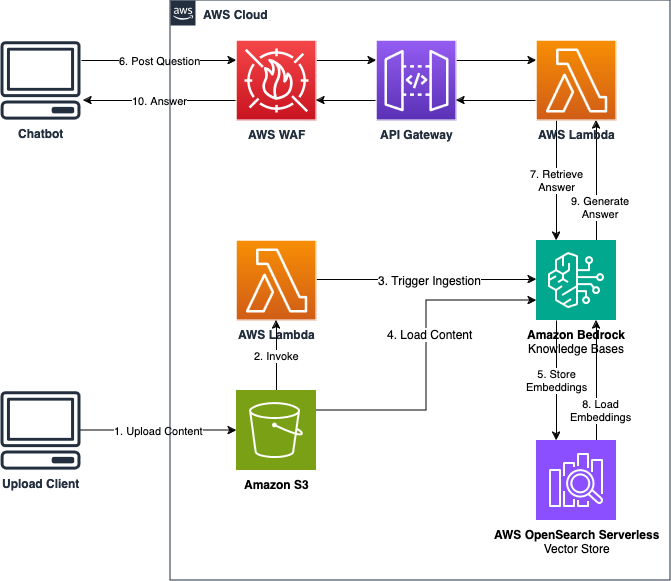

In [11]:
Image("content/Chatbot-Architecture.png", width="60%")

In [12]:
prompt = "The image is an AWS architecture diagram to build a chatbot using AWS services. Which service serves as a vector database for the chatbot?"
image_binary, image_type = prepare_image("content/Chatbot-Architecture.png")
response = invoke_nova_lite_multimodal(prompt=prompt, images=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

<i>The AWS OpenSearch Serverless Vector Store serves as a vector database for the chatbot. It stores embeddings, which are vector representations of the content uploaded by the user. These embeddings are used to retrieve relevant answers to the user's questions.</i>

#### Limitation with GIFs Content

Multimodal models like Amazon Nova, have the ability to process and understand multiple types of input data, such as text, images, and audio. However, when it comes to video or GIF data, there is a limitation in their native ability to analyze individual frames.

Videos and GIFs are essentially sequences of images or frames played in rapid succession to create the illusion of motion. Each frame can contain unique visual information, such as the movement of objects, changes in lighting or colors, or the appearance or disappearance of elements.

Several multimodal models, including Nova models, only parse the first frame of a GIF when prompted with it. This limitation prevents the model from analyzing each frame natively and loses the ability to explain the complete animation.

A possible solution could be stacking all the frames into a single image and prompting the model with it. However, that makes the image very complicated, and the model may not be able to analyze the slight differences in each subsequent frame to understand the animation. Recently, there have been a few models that come with the ability to process and analyze video frames to describe videos.

Let's try to prompt Amazon Nova Lite with this [GIF](https://commons.wikimedia.org/wiki/File:SdKfz_250-1_(Neu)_(3D-animated).gif):

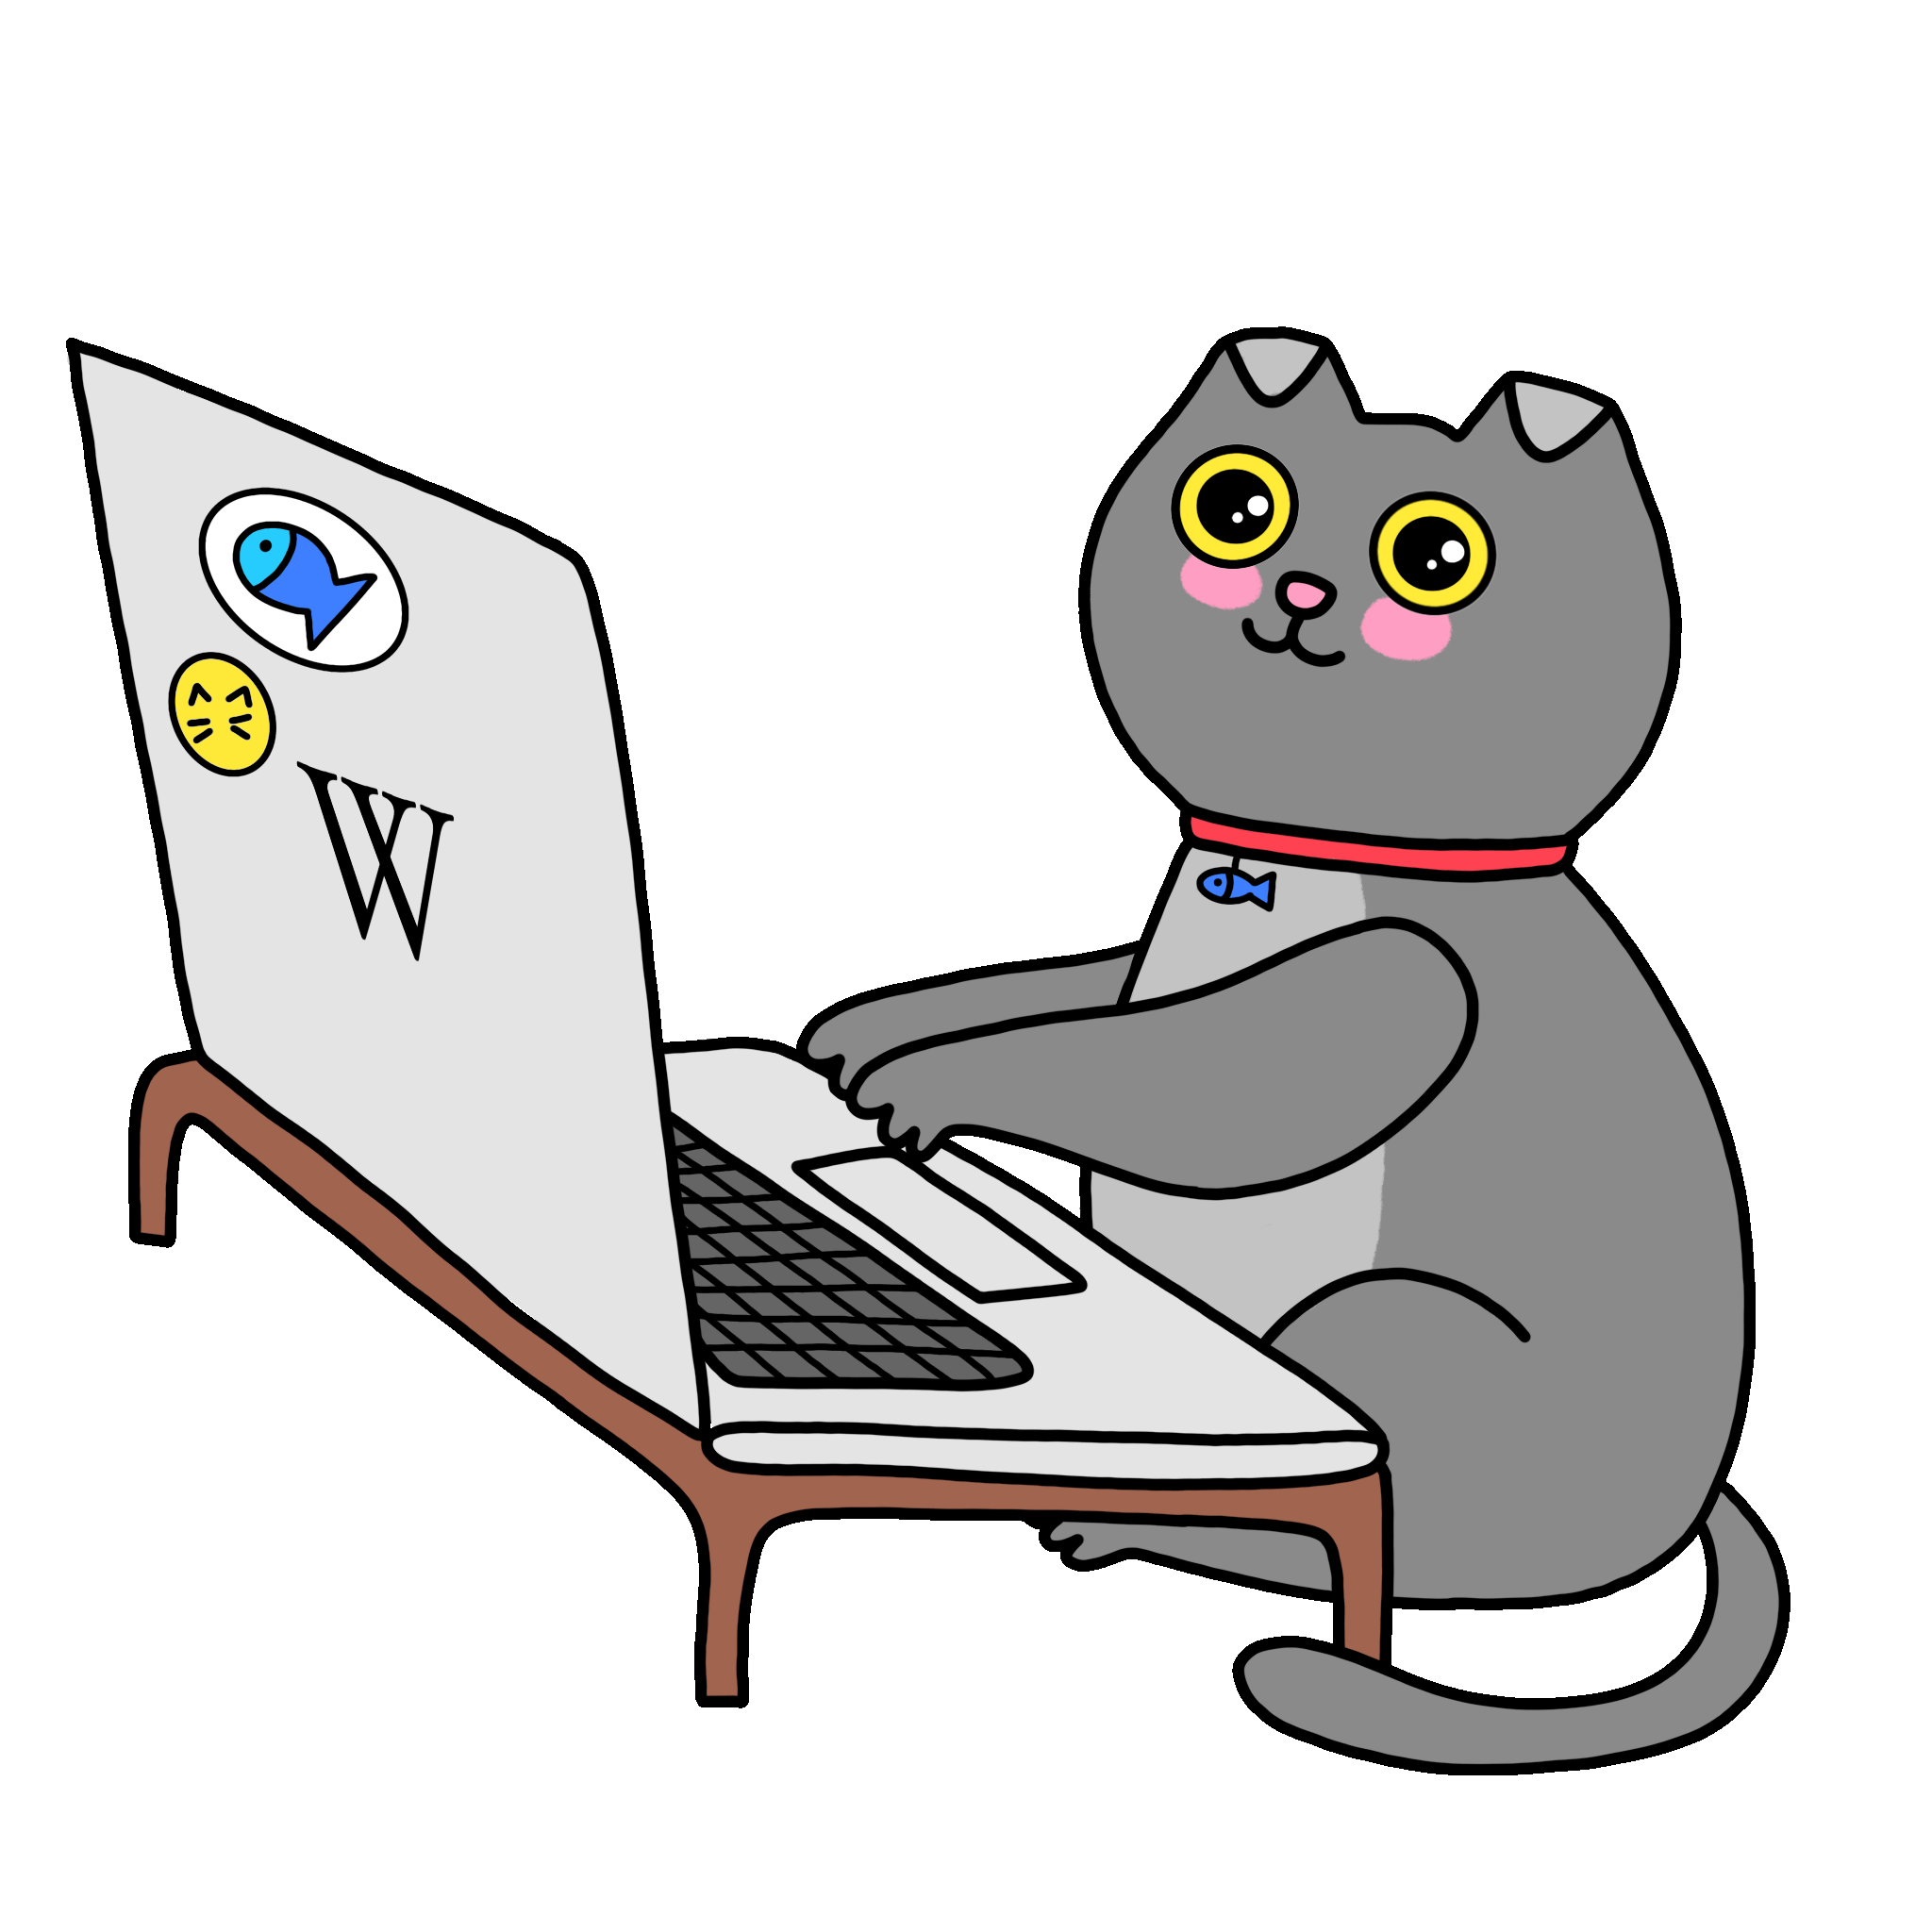

In [13]:
Image("content/Cat_Laptop.gif", width=300)

In [14]:
prompt = "Explain this GIF."
image_binary, image_type = prepare_image("content/Cat_Laptop.gif")
response = invoke_nova_lite_multimodal(prompt=prompt, images=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

<i>The GIF depicts a cat sitting on a desk, using a laptop. The cat is wearing a red collar with a fish design, and it has a fish icon on the laptop screen. The cat's eyes are yellow, and it has a pink nose and cheeks. The cat's paws are on the laptop's keyboard, and it appears to be typing. The background is black, and the cat's shadow is cast on the desk. The cat is likely using the laptop for work or browsing the internet.</i>

### 6.2 Information Retrieval

With documents, these models excel at processing complex layouts and understanding the relationship between text and visual elements. They can extract text from images, understand tables, charts, and graphs, and even interpret hand-written notes. By combining textual and visual understanding, these models provide a comprehensive understanding of the document, making information extraction accurate and contextually aware. 

The key advantage of multimodal models lies in their ability to bring together disparate sources of information and make inferences that were previously challenging for traditional, single-modality AI systems. 

Here we will use the [Open-LLM-Leaderboard](https://github.com/VILA-Lab/Open-LLM-Leaderboard) results presented by Myrzakhan et. al.

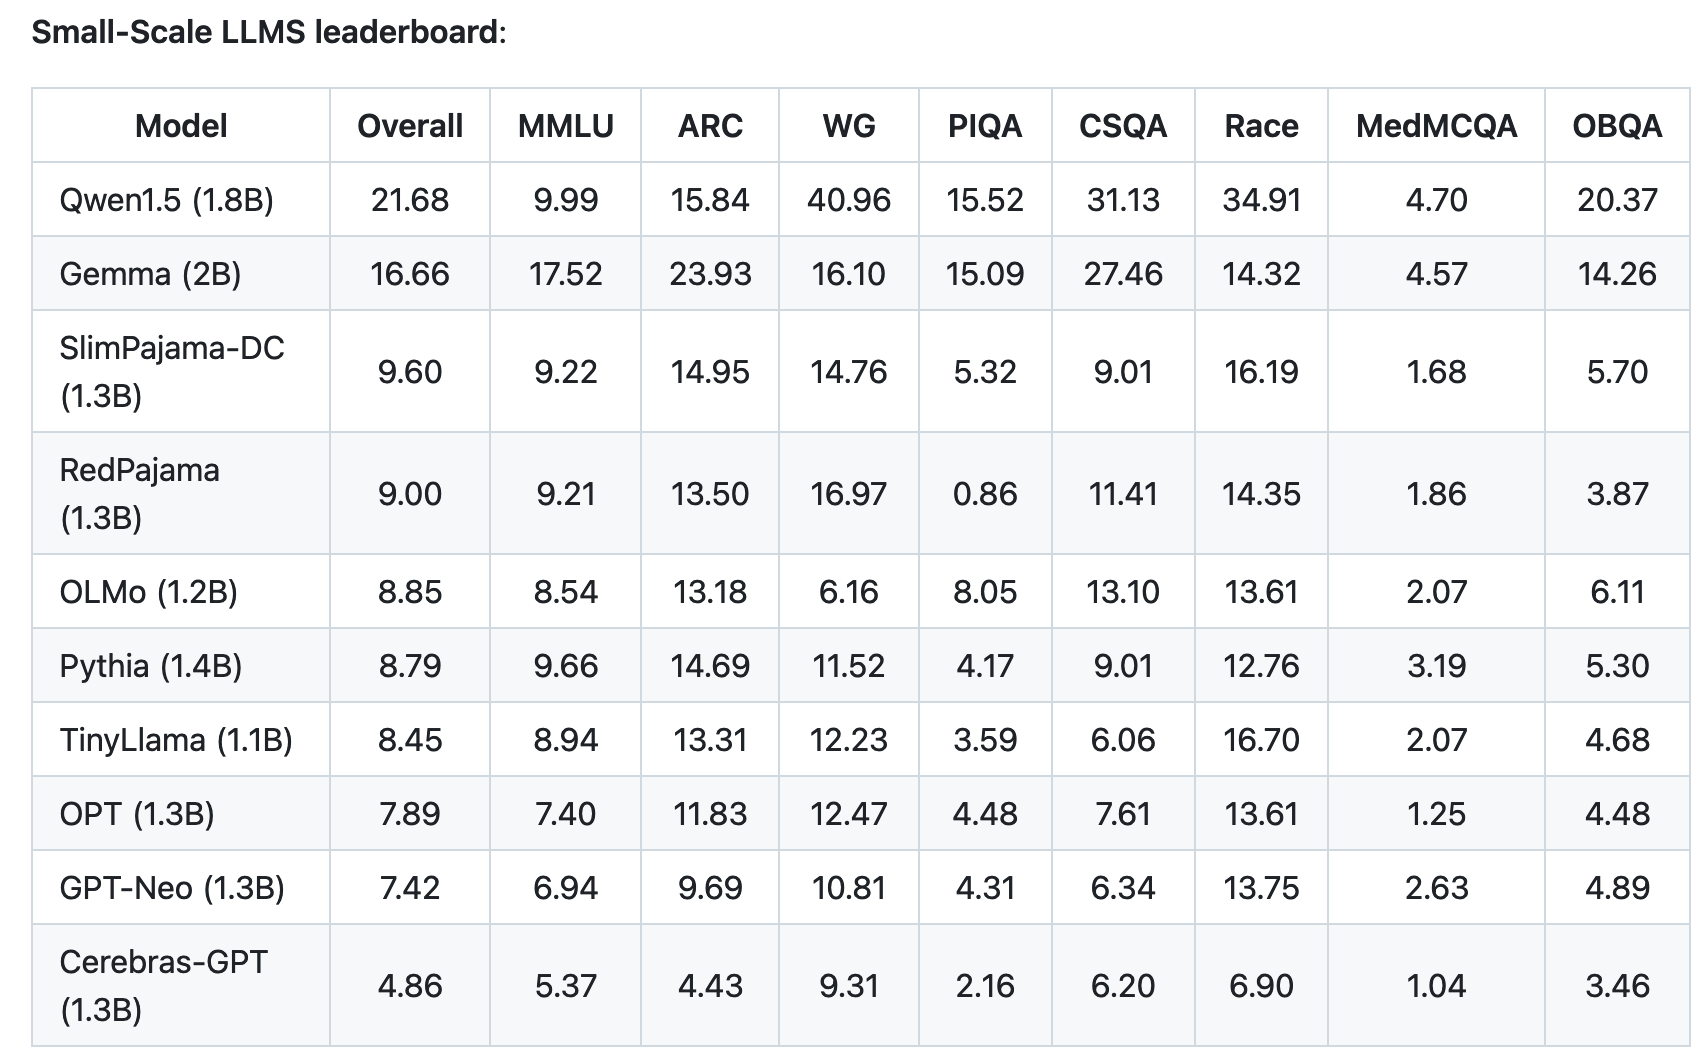

In [15]:
Image("content/Open-LLM-Leaderboard.png", width=800)

In [16]:
prompt = """The image depicts a leaderboard measuring the performance of various open-source LLMs on evaluation tasks such as MMLU, ARC, WG, etc. \
How did OLMo score on MMLU? Find the model name in the first column and find the corresponding evaluation metric in the MMLU column."""

image_binary, image_type = prepare_image("content/Open-LLM-Leaderboard.png")
response = invoke_nova_lite_multimodal(prompt=prompt, images=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

<i>According to the image, OLMo scored 8.54 on MMLU.</i>

### 6.3 Text Extraction and Transcription

For applications such as text extraction, these models can identify and extract relevant information from documents, images, or even videos. They excel at recognizing and interpreting text within complex layouts, such as tables, forms, or infographics. By understanding the context and structure of the source material, the models can accurately extract specific data points, summaries, or key information, making it readily available for further analysis or processing.

Let's try asking questions about the following [image](https://commons.wikimedia.org/wiki/File:ReceiptSwiss.jpg) of a receipt. The receipt shows that the customer purchased several items with a total cost of `54.50 CHF`. Let's ask questions about this receipt and observe the attention to details in the response.

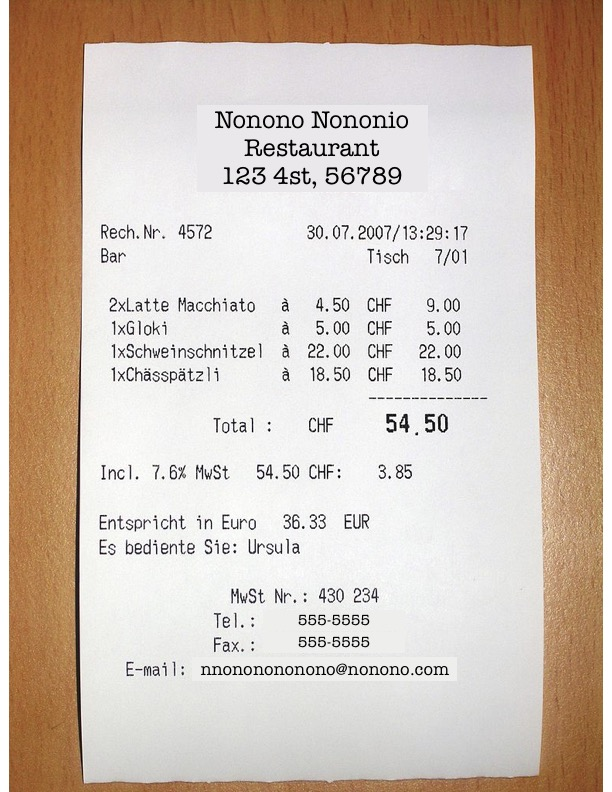

In [17]:
Image("content/Payment-receipt.jpg", width=500)

In [18]:
prompt = "What did the customer buy and how much did it cost in CHF?"
image_binary, image_type = prepare_image("content/Payment-receipt.jpg")
response = invoke_nova_lite_multimodal(prompt=prompt, images=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

<i>The customer bought the following items:
- 2x Latte Macchiato at 4.50 CHF each, totaling 9.00 CHF
- 1x Gloki at 5.00 CHF
- 1x Schweinschnitel at 22.00 CHF
- 1x Chässpätzli at 18.50 CHF

The total cost in CHF was 54.50 CHF.</i>

### 6.4 Analyze Charts and Graphs

Multimodal models are now being leveraged to analyze and interpret charts and graphs, offering a powerful way for understanding complex data visualizations. With their advanced capabilities, these models can provide valuable insights and support data-driven decision-making.

These models can identify and classify different types of visualizations, including bar graphs, pie charts, line graphs, and scatter plots, among others. By understanding the structural and visual elements, these models can extract crucial information, such as labels, legends, data values, and their relationships. 

One of the key strengths of multimodal models lies in their ability to provide contextual understanding. They can interpret chart titles, axis labels, and captions to grasp the underlying narrative of the visualization. By combining this with their text and image analysis capabilities, they can explain the insights presented, identify trends and patterns, and even generate descriptive summaries or highlight key takeaways. 

Moreover, these models can assist in comparing and contrasting multiple charts, identifying similarities, and relationships between datasets. This capability is particularly useful for spotting anomalies, making predictions, or generating insights that might otherwise be difficult to discern. By bringing together text, image, and even tabular data interpretation, multimodal models enhance the accessibility and comprehension of chart-based information, enabling users to make more informed decisions.

We will use the following [chart](https://commons.wikimedia.org/wiki/File:Land_vs_Ocean_Temperature.svg) illustrating how global average temperatures on the land surface and ocean surface have changed over the years. The chart is plotted at intervals of 10 years from 1950 to 2020. The chart shows that the average global temperatures on the land surface and ocean surface have steadily been increasing since 1950.

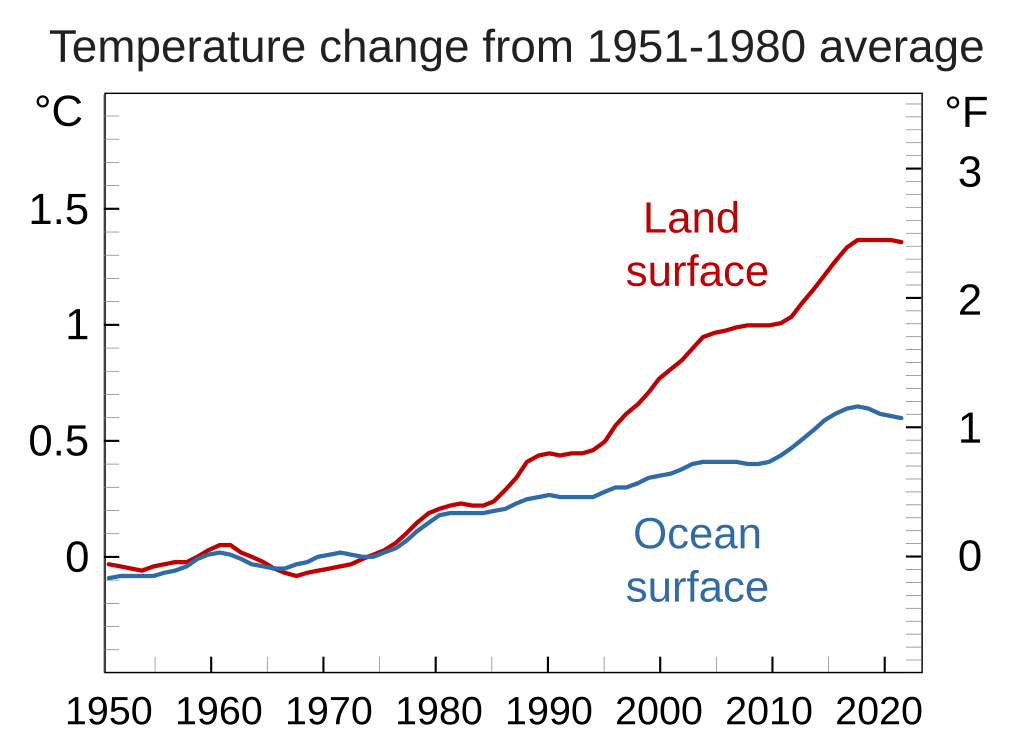

In [19]:
Image("content/Chart-data.png", width=800)

In [20]:
prompt = "Explain the trend of the plot."
image_binary, image_type = prepare_image("content/Chart-data.png")
response = invoke_nova_lite_multimodal(prompt=prompt, images=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

<i>The plot shows the temperature change from the 1951–1980 average for both land and ocean surfaces. The temperature change for the land surface is represented by the red line, and the temperature change for the ocean surface is represented by the blue line. The plot shows that the temperature change for the land surface has been increasing over time, while the temperature change for the ocean surface has been relatively stable. The temperature change for the land surface has increased by about 1.5 degrees Celsius from 1951–1980 to 2020, while the temperature change for the ocean surface has increased by about 0.5 degrees Celsius over the same period.</i>

### 6.5 Improve Accessibility

Multimodal models are revolutionizing the field of accessibility by generating descriptive content for images and scenes, making digital content more inclusive for all users. 

One of the key applications of these models is in the creation of alt-text for images. By analyzing the visual content, multimodal models can generate descriptive alt-text that conveys the image's key information. This alt-text is crucial for individuals with visual impairments, as it allows them to understand the context and significance of images through assistive technologies like screen readers. The models can identify objects, recognize scenes, and describe the image's composition, ensuring a rich and detailed portrayal. 

Additionally, these models can provide detailed scene descriptions, offering a narrative-like explanation of what is happening in a given image or video frame. This goes beyond simple object recognition by capturing the atmosphere, actions, and relationships between elements. Scene descriptions are particularly beneficial for those with visual or cognitive disabilities, as they paint a comprehensive mental picture, enhancing their understanding and engagement with the content. 

Let's consider the following [image](https://commons.wikimedia.org/wiki/File:Asl_alphabet_gallaudet.svg) representing the ASL (American Sign Language) alphabets, laid out by Darren Stone.

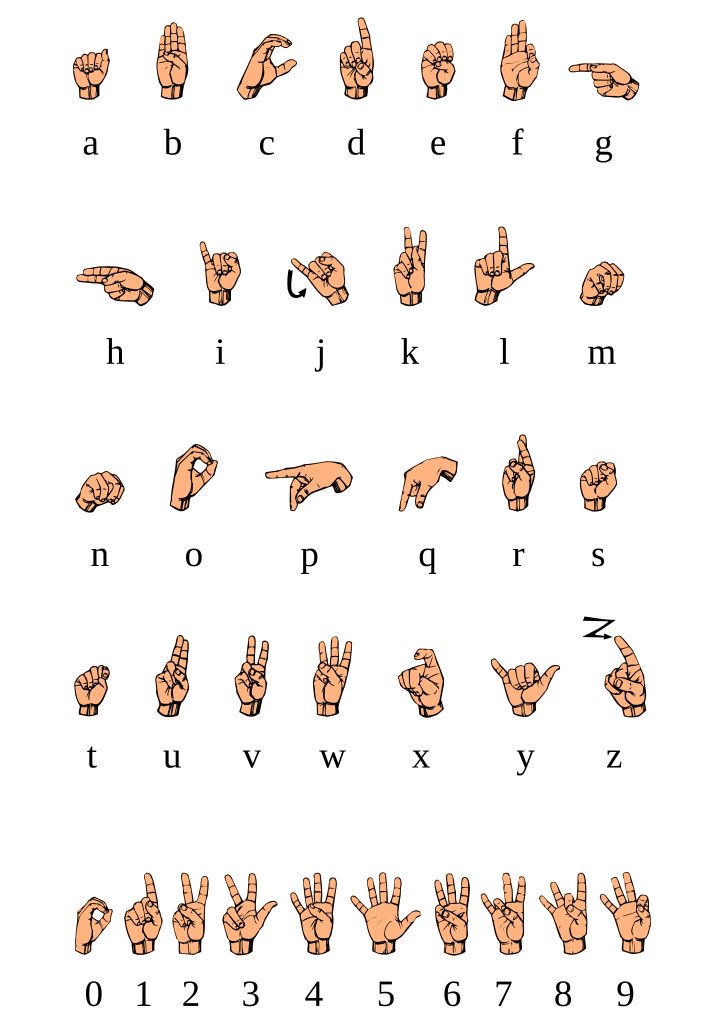

In [21]:
Image("content/asl.png", width=800)

In [22]:
prompt = "Produce alt-text for the given image following the guidelines."
guidelines = """ Guidelines for alt-text:
- Be succinct but convey the same information a sighted customer receives from the image.
- Keep alt text length to 155 characters or less for SEO reasons.
- Don't duplicate text already in the content.
- Avoid phrases like "image of ..." or "graphic of ..." to describe the image. Screen readers already indicate that alt text is part of an image.
- Include punctuation when needed. When screen readers encounter punctuation, they pause before continuing.
- Avoid using all-caps in alt text. Some screen readers read capital letters individually.
"""

image_binary, image_type = prepare_image("content/asl.png")
response = invoke_nova_lite_multimodal(prompt=prompt, images=image_binary, image_types=image_type)
Markdown("<i>"+response+"</i>")

<i>The image displays a series of hand gestures representing the alphabet and numbers. The alphabet is shown in two rows, with the first row containing the letters A through G, and the second row containing the letters H through Z. Each letter is accompanied by a corresponding hand gesture. Below the alphabet, there is a row of numbers from 0 to 9, each with its own hand gesture. The hand gestures are designed to be easily recognizable and are commonly used in sign language.</i>

### 6.6 Complex Reasoning and Analysis of Documents

Multimodal models are effective tools for parsing, analyzing, and retrieving information from documents such as PDFs, offering a seamless way to extract valuable insights from a variety of sources. 

One of the key strengths of these models is their ability to process and understand structured and unstructured data within PDFs. They can parse through tables, forms, charts, and free-form text, recognizing and extracting relevant information. Whether it's extracting specific data points, identifying patterns, or understanding contextual relationships, multimodal models provide a comprehensive understanding of the document's content. 

Another advantage is their capability to interpret and analyze visual elements, such as graphs, diagrams, and images, often found in PDFs. By combining image recognition with textual analysis, these models can explain and provide insights from visual representations, making the information more accessible and actionable. This is particularly useful for industries that rely on visual data, such as engineering, architecture, or scientific research. 

By leveraging the power of multimodal AI, the process of parsing, analyzing, and retrieving information from PDFs becomes more efficient and robust. Models like Amazon Nova enable users to unlock valuable insights, make data-driven decisions, and easily access the information they need, regardless of the document's format or structure. This enhances productivity, facilitates knowledge sharing, and improves the overall user experience when working with PDF documents.

Let's try to analyze the following [PDF](https://docs.aws.amazon.com/bedrock/latest/userguide/titan-text-models.html) about Amazon's Titan Models.

In [23]:
IFrame("content/Titan Models-Docs.pdf", width=600, height=800)

In [24]:
# Helper function to convert pdf to images
def pdf2img(pdf_path, pdf_pages_dir):
    import pypdfium2 as pdfium
    from PIL import Image as pilimage
    
    pdf = pdfium.PdfDocument(pdf_path)

    if not os.path.exists(pdf_pages_dir):
        os.makedirs(pdf_pages_dir)

    resolution = pdf.get_page(0).render().to_numpy().shape
    scale = 1 if resolution[0] >= 1620 or resolution[1] >=1620 else 300/72
    n_pages = len(pdf)
    for page_number in range(n_pages):
        page = pdf.get_page(page_number)
        pil_image = page.render(
            scale=scale,
            rotation=0,
            crop=(0, 0, 0, 0),
            may_draw_forms=False,
            fill_color=(255, 255, 255, 255),
            draw_annots=False,
            grayscale=False,
        ).to_pil()
        width, height = pil_image.size
        pil_image = pil_image.resize((width//2*2, height//2*2), pilimage.LANCZOS)
        pil_image.save(os.path.join(pdf_pages_dir, "page_{}.png".format(str(page_number).zfill(3))))

In [25]:
def analyse_pdf(prompt, pdf_path):
    
    pdf_pages_dir = "pdf_pages"
    
    pdf2img(pdf_path=pdf_path, pdf_pages_dir=pdf_pages_dir)
        
    image_paths = [os.path.join(pdf_pages_dir, file) for file in sorted(os.listdir(pdf_pages_dir))]
    image_types = []
    images = []
    for img in image_paths:
        image_types.append("png")
        with open(img, "rb") as f:
            images.append(f.read())
        
    response = invoke_nova_lite_multimodal(prompt=prompt, images=images, image_types=image_types)
    return response

In [26]:
pdf_path = "content/Titan Models-Docs.pdf"
prompt = "What is the 'max token' value for Titan Premier?"

response = analyse_pdf(prompt, pdf_path)
Markdown("<i>"+response+"</i>")

<i>32K</i>

## Activity: Text and image search

    

    ![Activity](../mlu_utils/activity.png) 
    Analyzing PDFs this way can be quite challenging as the model is attempting to process multiple images which contain a lot of text. 

        Try a few more prompts to explore the model's capability in answering specific questions about the content in the PDF.

In [27]:
############## CODE HERE ####################

prompt = "review this PDF for errors"

response = analyse_pdf(prompt, pdf_path)
Markdown("<i>"+response+"</i>")


############## END OF CODE ##################

<i>Here is a review of the PDF for any errors:

1. The headings and subheadings are clear and well-structured. The topics are logically organized.

2. The model descriptions are comprehensive and provide useful details like model ID, max tokens, languages supported, use cases, and inference parameters. 

3. There are no obvious typos or grammatical errors in the text.

4. The links to the AWS AI Service Cards and prompt engineering guidelines are correctly formatted.

5. The note about the Amazon Titan Text Embeddings models not supporting inference parameters is a useful clarification.

6. The list of languages supported by the Amazon Titan Text Embeddings v2 model is extensive and covers a wide range of languages.

7. The page numbers at the bottom of each page are consistent and correctly formatted.

Overall, the PDF appears to be well-written and free of major errors. The information is presented clearly and the topics are covered comprehensively. The only minor issue is the note about the lack of inference parameters for the text embeddings models, but this is a useful clarification.

Hope this review helps! Let me know if you have any other questions.</i>

## 7. Quiz Questions

Well done on completing the lab! Now, it's time for a brief knowledge assessment.

    
        ![Challenge](../mlu_utils/challenge.png)
    
    
        

#### Try it Yourself!

        Answer the following questions to test your understanding of multimodal prompting.

In [28]:
import sys
sys.path.append('..')
from mlu_utils.quiz_questions import *

lab5_question1.display()
lab5_question2.display()

HTML(value='\n        <style>\n            .widget-button {\n                text-align: left !important;\n   …

HTML(value='\n        <style>\n            .widget-button {\n                text-align: left !important;\n   …

# Thank you!
